**Zaimplementuj algorytm genetyczny z ANFIS**

Wymagania: 

- kodowanie binarne bądź dyskretne/ciągłe genotypu 
- parametryzacja długości genotypu, wielkości populacji 
- krzyżowanie k-punktowe z prawdopodobieństwem pk, losowanie locusów bez zwracania 
- mutacja m-punktowa z prawdopodobieństwem pm, losowanie locusów bez zwracania 
- selekcja: 
    - rankingowa: n najlepszych osobników zastępuje w populacji n najgorszych 
    - koło ruletki z uwzględnieniem funkcji transformującej wartości funkcji przystosowania 
- warunek stopu: liczba pokoleń, opcjonalnie docelowa wartość funkcji przystosowania, % najlepszych osobników w populacji 
Użyj algorytmu do optymalizacji ANFIS.

**Importy**

In [5]:
# -*- coding: utf-8 -*-
import numpy as np
from scipy.optimize import minimize, basinhopping
from scipy.stats import variation
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import permutations, combinations
import time
from sklearn.model_selection import train_test_split
from helps_and_enhancers import calculate_combinations, my_reshape
from operators import productN
from types import SimpleNamespace
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids, FuzzyInputVariable_List_Trapezoids
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from goal_function_object import *
import pandas as pd
import random
from collections import defaultdict, Counter
import matplotlib.pyplot as plt


**Kod Genetyczny**

In [6]:
def create_population(x0, bounds, pop_size):
    dim = len(x0)
    low = [b[0] for b in bounds]
    high = [b[1] for b in bounds]
    
    operations = [(task_id, op_idx)
                  for task_id in range(dim)
                  for op_idx in range(2)]  # 2 because we have low and high bounds
    
    population = []
    for _ in range(pop_size):
        individual = []
        for i in range(dim):
            # Dla każdego parametru losujemy wartość między jego dolną a górną granicą
            value = np.random.uniform(low[i], high[i])
            individual.append(value)
        population.append(individual)
    
    return population, dim, low, high


def evaluate_population(pop, goal_function, args):
    fitness_scores = []
    for individual in pop:
        score = goal_function(individual, *args)
        fitness_scores.append(score)
    return fitness_scores


def roulette_selection(pop, fitness_scores):
    max_score = max(fitness_scores)
    adjusted_scores = [max_score - f for f in fitness_scores]
    
    if sum(adjusted_scores) == 0:
        return pop[np.random.randint(0, len(pop))].copy()
    
    probabilities = [f / sum(adjusted_scores) for f in adjusted_scores]
    r = np.random.random()
    cumulative = 0
    for idx, p in enumerate(probabilities):
        cumulative += p
        if r <= cumulative:
            return pop[idx].copy()
    
    return pop[-1].copy()


def k_point_crossover(parent1, parent2, dim, k_points, pk):
    if np.random.random() >= pk:
        return parent1.copy() 
    
    cross_points = sorted(np.random.choice(range(1, dim), k_points, replace=False))
    
    child = parent1.copy()
    swap = False
    start = 0
    
    for point in cross_points + [dim]:
        if swap:
            child[start:point] = parent2[start:point]
        start = point
        swap = not swap
        
    return child


def smart_mutate(child, low, high, gen, niter, m_points, pm):
    if np.random.random() >= pm:
        return child
    
    dim = len(child)
    mut_points = np.random.choice(range(dim), m_points, replace=False)
    
    for idx in mut_points:
        sigma = 0.1 * (high[idx] - low[idx]) * (1 - gen/niter)
        new_value = child[idx] + np.random.normal(0, sigma)
        child[idx] = max(min(new_value, high[idx]), low[idx])
    
    return child


def genetic_algorithm(goal_function, x0, minimizer_kwargs=None, niter=100, niter_success=None):
    bounds = minimizer_kwargs.get('bounds', None) if minimizer_kwargs else None
    args = minimizer_kwargs.get('args', ()) if minimizer_kwargs else ()

    if not isinstance(args, tuple):
        args = (args,) 
    if bounds is None: 
        raise ValueError("Bounds są wymagane")
    
    pop_size = 100
    pk = 0.8
    k_points = 2
    pm = 0.2
    m_points = 3
    n_rank = 10
    
    pop, dim, low, high = create_population(x0, bounds, pop_size)
    
    best_solution = None
    best_fitness = float('inf')
    history = []
    nfev = 0
    
    for gen in range(niter):
        fitness_scores = evaluate_population(pop, goal_function, args)
        nfev += len(pop)
        
        min_idx = np.argmin(fitness_scores)
        if fitness_scores[min_idx] < best_fitness:
            best_fitness = fitness_scores[min_idx]
            best_solution = pop[min_idx].copy()
        history.append(best_fitness)
        
        if niter_success is not None and best_fitness <= niter_success:
            break
            
        threshold = best_fitness * 1.1
        num_good = sum(1 for f in fitness_scores if f <= threshold)
        if num_good >= 0.7 * pop_size:
            break
        
        sorted_indices = sorted(range(len(fitness_scores)), key=lambda i: fitness_scores[i])
        best_individuals = [pop[i].copy() for i in sorted_indices[:n_rank]]
        
        next_pop = []
        while len(next_pop) < pop_size - n_rank:
            parent1 = roulette_selection(pop, fitness_scores)
            parent2 = roulette_selection(pop, fitness_scores)
            child = k_point_crossover(parent1, parent2, dim, k_points, pk)
            child = smart_mutate(child, low, high, gen, niter, m_points, pm)
            next_pop.append(child)
        
        pop = next_pop + best_individuals
    
    result = SimpleNamespace()
    result.x = np.array(best_solution) 
    result.fun = best_fitness
    result.nit = len(history)
    result.nfev = nfev
    result.history = history
    
    return result

**Kod Anfis**

In [7]:
class ANFISGenetic:
    
    def __init__(self, inputs, training_data: np.ndarray, expected_labels: np.ndarray, operator_function=productN, operator_init_value=0.5):
        self.input_list = inputs
        self.input_number = len(inputs)
        self.training_data = training_data
        self.expected_labels = expected_labels
        
        self.premises = []
        for i in range(self.input_number):
            self.premises.append(self.input_list[i].get())

        self.nodes_number = np.prod([inp.n_functions for inp in self.input_list])
        
        self.operator_function=operator_function
        
        #self.tsk = np.ones((self.nodes_number ,self.input_number+1))
        self.tsk = np.random.random((self.nodes_number ,self.input_number+1))
        
        self.op  = [operator_init_value]*self.nodes_number

        self.calculate_aids()

    #Wyswietlanie funkcji przynależnosci
    def show_inputs(self):
        plt.figure()
        for i in range(self.input_number):
            plt.subplot(self.input_number, 1, i+1)
            self.input_list[i].show()
            plt.legend()
        plt.show()

    def set_premises_parameters(self, fv):
        fv = np.array(fv).reshape(np.shape(self.premises))
        self.premises=fv
        for i in range(self.input_number):
            self.input_list[i].set(*fv[i])
             
    def calculate_aids(self):
        self.premises_combinations = np.array(calculate_combinations(self))[:,::-1]

    def output_to_labels(self, y_pred):
        rounded = np.round(y_pred.flatten()).astype(int)
        r_shape = np.shape(rounded)
        return np.max((np.min((rounded , np.ones(r_shape)),axis=0), np.zeros(r_shape)),axis=0)#clamp 0-1       
               
    def anfis_estimate_labels(self, fv, op, tsk) -> np.ndarray:

        data = self.training_data

        self.set_premises_parameters(fv)
        tsk=np.reshape(tsk,np.shape(self.tsk))
        memberships = [self.input_list[x].fuzzify(data[x]) for x in range(self.input_number)]
        
        #Wnioskowanie
        arguments = []
        for premises in self.premises_combinations:
            item = []
            for i in range(len(premises)):
                item.append(np.array(memberships[i])[:,premises[i]])
            arguments.append(   item  )

        arguments = np.transpose(arguments, (1,2,0))
        
        R=self.operator_function(arguments, op)
        
        #Normalizacja normalizacja poziomów aktywacji reguł
        Rsum = np.sum(R, axis=1, keepdims=True)

        Rnorm = R / Rsum
        Rnorm[(Rsum==0).flatten(),:] = 0
        # wylicz wartoci przesłanek dla każdej próbki
        
        dataXYZ1 = np.vstack((self.training_data,np.ones(len(self.training_data[0])))).T
        Q = np.dot(dataXYZ1, tsk.T) 
        
        # wyznacz wyniki wnioskowania dla każdej próbki
        result = (Q * Rnorm).sum(axis=1, keepdims=True)
    
        return result.T    
        
    def show_results(self, color=None):
        
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        
        if color is None:
            color = [[1,0,0] if cc else [0,1,0] for cc in self.expected_labels]

        result = self.anfis_estimate_labels(self.premises,self.op,self.tsk)
        
        #ax.scatter(np.array(self.training_data)[:,0], np.array(self.training_data)[:,1], result, c=rgb)
        ax.scatter(self.training_data[0], self.training_data[1], result, c=color)
        
        plt.show()
    
    def set_training_and_testing_data(self, training_data, expected_labels):
        self.training_data = training_data
        self.expected_labels = expected_labels
        
    def train(self, global_optimization: bool, learn_premises: bool, learn_operators: bool, learn_consequents: bool, n_iter=100, bounds_premises=None):
        
        x1 = [ item for sublist in self.premises for item in sublist ]
        x1 = np.array(x1).flatten()
        x2 = self.op
        x3 = self.tsk.flatten()
          
        if bounds_premises is None:
            bfv = [(0,4)]*len(x1)
        else:
            bfv = bounds_premises
        bop  = [(0.0,2.0)]*len(x2)
        btsk = [(0,2)]*len(x3)
        
        niter_success=100
            
        if learn_premises and learn_operators and learn_consequents:
            x0 = np.hstack((x1,x2,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop + btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = genetic_algorithm(goal_premises_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
            
        elif learn_premises and learn_operators:
            x0 = np.hstack((x1,x2))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = genetic_algorithm(goal_premises_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]

        elif learn_premises and learn_consequents:
            x0 = np.hstack((x1,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv + btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = genetic_algorithm(goal_premises_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter)#, niter_success=niter_success)
            else:
                res = minimize(goal_premises_consequents, x0, method='SLSQP', bounds=bounds, args=self, tol=1e-6)

            self.set_premises_parameters(res.x[:self.end_x1]) ##zmiana funkcji
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))

        elif learn_operators and learn_consequents:
            print("4")
            x0 = np.hstack((x2,x3))
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop + btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = genetic_algorithm(goal_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
        
        elif learn_premises:
            x0 = x1
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = genetic_algorithm(goal_premises, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:].reshape(np.shape(self.premises)))

        elif learn_operators:
            x0 = x2
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = genetic_algorithm(goal_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[:]
            
        elif learn_consequents:
            x0 = x3
            self.end_x1 = 0
            self.end_x2 = 0
            
            bounds = btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self), "tol":1e-03}
                res = genetic_algorithm(goal_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.tsk=res.x[:].reshape(np.shape(self.tsk))
            
        else:
            print("Error")
            assert(0)
            
        print("Optymalizacja zakończona!")
        print("z blędem:  ", res.fun)
        print("Liczba ew: ", res.nfev)
        print("Liczba it: ", res.nit)


**Sprawdzenie genetycznego** 

Tabliczka: 2x2


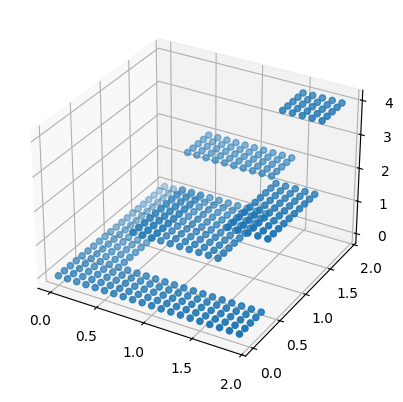

C:\Users\Filip\AppData\Local\Temp\ipykernel_16736\2786001533.py:70: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   63.315935250040646
Liczba ew:  4600
Liczba it:  46


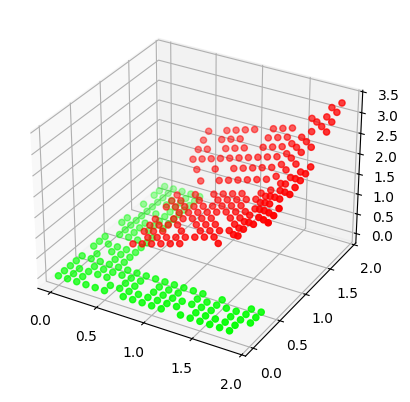

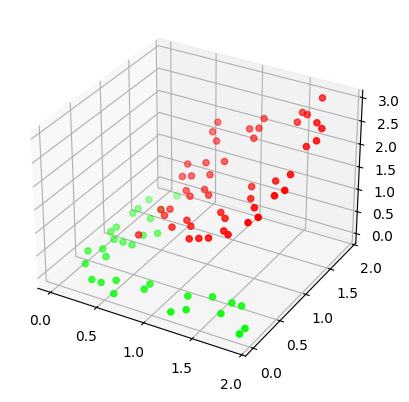

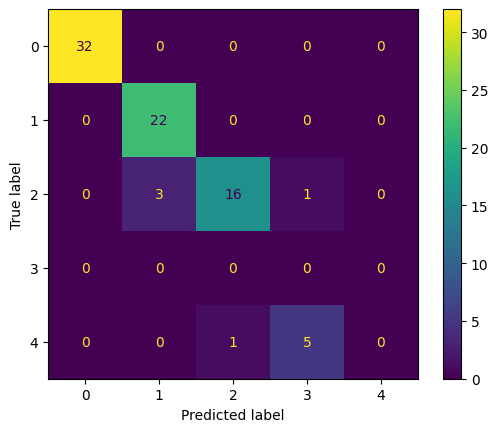

Tabliczka: 3x3


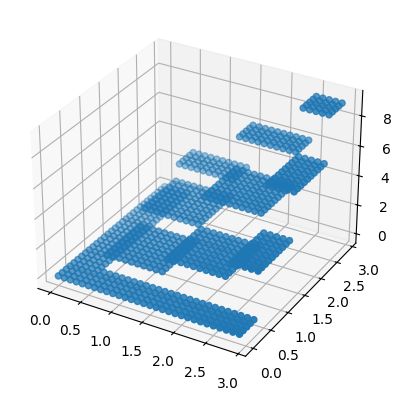

C:\Users\Filip\AppData\Local\Temp\ipykernel_16736\2786001533.py:70: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   399.7659501098309
Liczba ew:  3000
Liczba it:  30


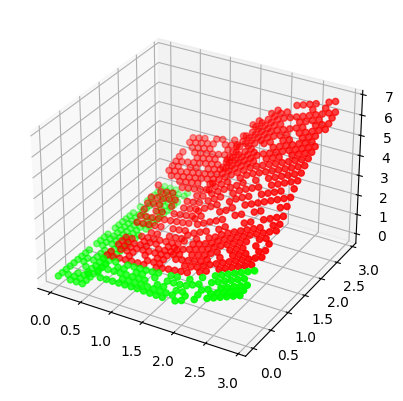

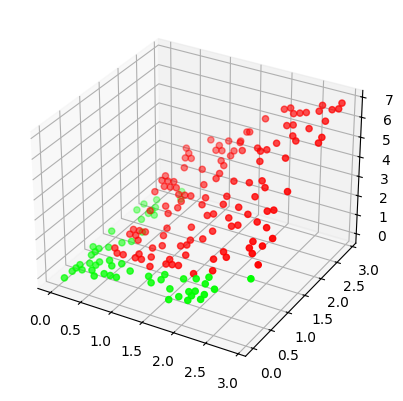

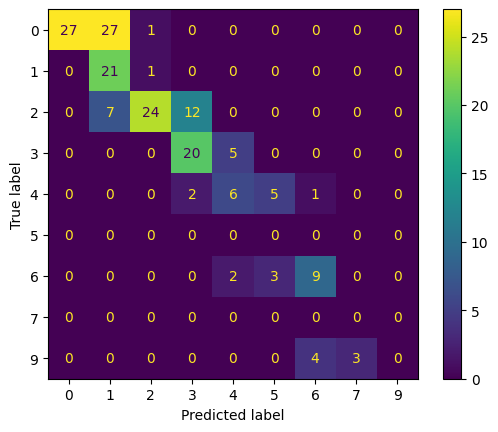

Tabliczka: 4x4


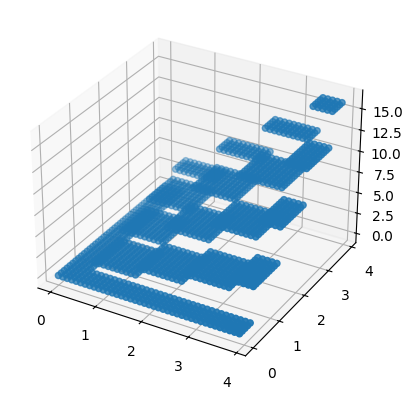

C:\Users\Filip\AppData\Local\Temp\ipykernel_16736\2786001533.py:70: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   1458.252089213272
Liczba ew:  2400
Liczba it:  24


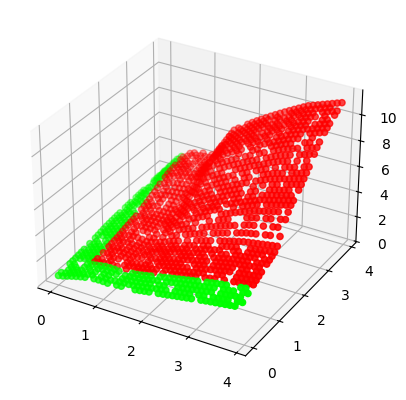

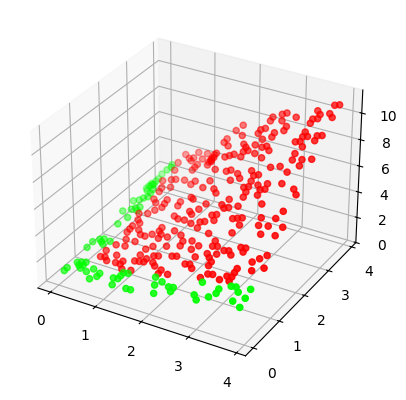

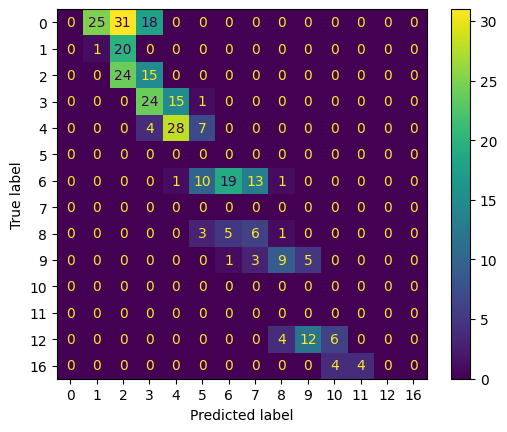

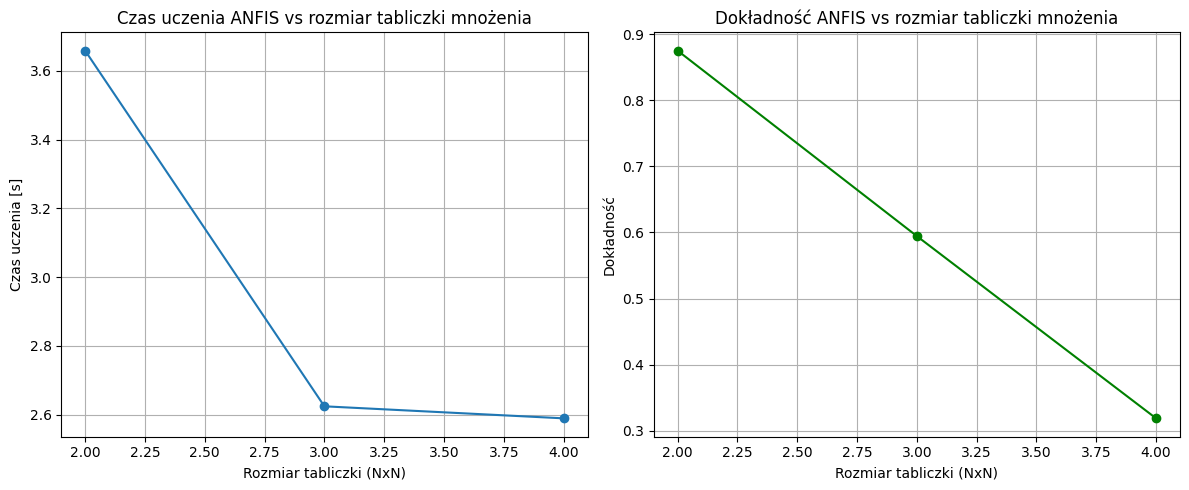

In [8]:
from sklearn.metrics import accuracy_score

sizes = [2, 3, 4]
times = []
accuracies = []

mf1 = [
        [-0.25, 0.125, 0.125, 0.25], 
        [0.25, 0.125, 0.1, 0.1], 
        [0.5, 0.25, 0.1, 0.1], 
        [0.75, 0.25, 0.125, 1.25],
        [1.25, 0.75, -0.25, 1.25]
    ]
    
labels = ["L","H", "M", "S", "XL"]

def custom_round(val):
    return int(val + 0.5)

for size in sizes:
    print(f"Tabliczka: {size}x{size}")

    x = np.arange(0, size, 0.1)
    x,y = np.meshgrid(x, x)

    dataX = x.flatten()
    dataY = y.flatten()
    dataXY = np.column_stack((dataX,dataY))   

    data_labels = [custom_round(a) * custom_round(b) for a, b in dataXY]

    # for x in range(len(dataXY)):
    #     print(x, dataXY[x], data_labels[x])

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(dataX, dataY, data_labels)
    plt.show()

    # varX = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "XAxis", ["L","H"]) 
    # varY = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "YAxis", ["L","H"])

    varX = FuzzyInputVariable_List_Trapezoids(mf1[:size], "XAxis", labels[:size])
    varY = FuzzyInputVariable_List_Trapezoids(mf1[:size], "YAxis", labels[:size])

    X_train, X_test, y_train, y_test = train_test_split(dataXY, data_labels, test_size=0.2, random_state=25)

    fis = ANFISGenetic([varX, varY], X_train.T, y_train)

    start = time.time()
    fis.train(True, True, False, True, n_iter=30*size*size)
    end = time.time()
    times.append(end-start)
    fis.training_data = X_train.T
    fis.expected_labels = y_train
    fis.show_results()

    fis.training_data = X_test.T
    fis.expected_labels = y_test
    fis.show_results()

    y_pred = fis.anfis_estimate_labels(fis.premises,fis.op,fis.tsk)
    y_pred = list(map(round,y_pred.flatten()))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(sizes, times, marker='o')
axs[0].set_xlabel('Rozmiar tabliczki (NxN)')
axs[0].set_ylabel('Czas uczenia [s]')
axs[0].set_title('Czas uczenia ANFIS vs rozmiar tabliczki mnożenia')
axs[0].grid(True)

axs[1].plot(sizes, accuracies, marker='o', color='green')
axs[1].set_xlabel('Rozmiar tabliczki (NxN)')
axs[1].set_ylabel('Dokładność')
axs[1].set_title('Dokładność ANFIS vs rozmiar tabliczki mnożenia')
axs[1].grid(True)

plt.tight_layout()
plt.show()
